<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL3_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a deep learning pipeline for an image dataset (CIFAR-10). To run this notebook, do the following:
- Select the confiuration you want in the cell below.
- After that click the Colab `Run all` button (library installation and dataset loading are automated).
- The pipeline will run according to your configuration.
- See the final result in the last cell of this notebook.

If you want to rerun the pipeline with another configuration, you only need to run the last cell again after selecting your config.

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [1]:
import sys
import subprocess
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models
import timm

import ipywidgets as widgets
from IPython.display import display, clear_output

def pip_install(packages):
    """Installs packages quietly."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

pip_install(["scikit-learn", "pandas", "matplotlib", "seaborn", "torch", "torchvision", "tqdm"])

In [2]:
RND = 42
np.random.seed(RND)
random.seed(RND)
torch.manual_seed(RND)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)

Using device: cuda


## 1.2.&nbsp;Download and store the dataset

In [3]:
print("Downloading CIFAR-10 dataset and creating DataLoaders...")

transform_raw = transforms.Compose([transforms.ToTensor()])

train_full_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_raw
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_raw
)

# Split full training data into train and validation (85% / 15%)
train_size = int(0.85 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(RND)
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print(f"\nTotal training images: {len(train_full_dataset)}")
print(f"Split -> Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 170M/170M [00:04<00:00, 41.2MB/s]



Total training images: 50000
Split -> Train: 42500, Validation: 7500, Test: 10000



--- Starting EDA ---
Image shape (after transform): torch.Size([16, 3, 32, 32])
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


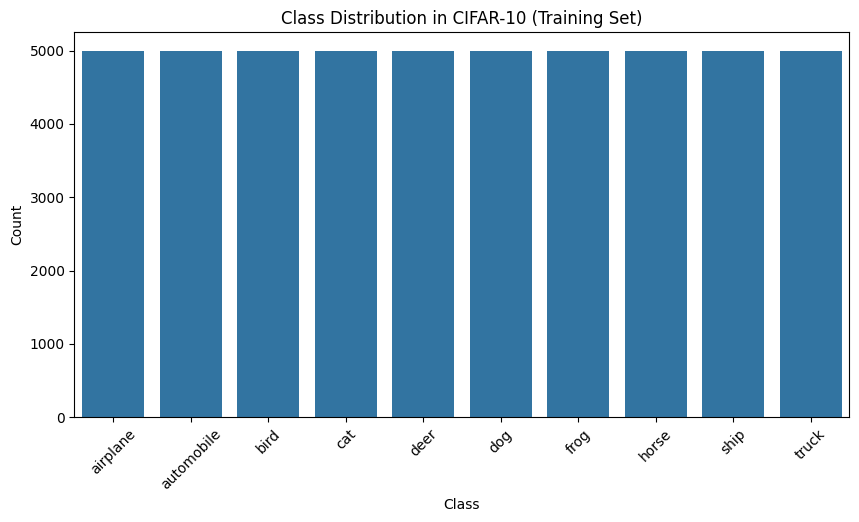


Displaying sample images (from validation set)...


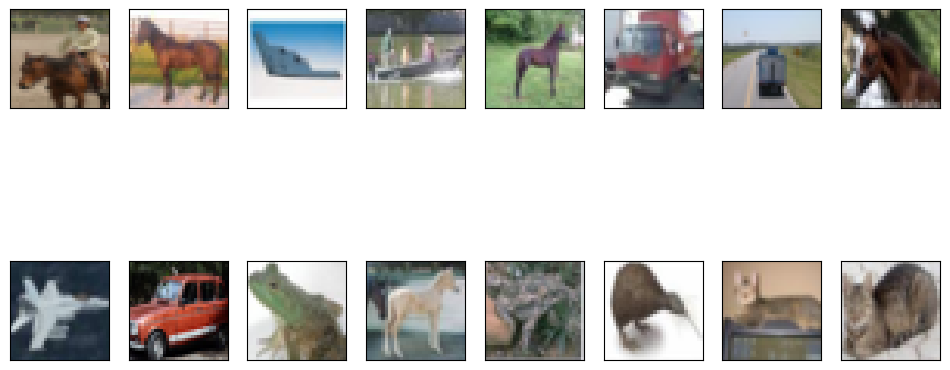

--- EDA Finished ---


In [4]:
print("\n--- Starting EDA ---")
print(f"Image shape (after transform): {next(iter(train_loader))[0].shape}")
print(f"Classes: {CLASS_NAMES}")

label_counts = pd.Series(train_full_dataset.targets).value_counts().sort_index()
label_counts.index = CLASS_NAMES

plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Class Distribution in CIFAR-10 (Training Set)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("\nDisplaying sample images (from validation set)...")

def imshow(img_batch):
    img_batch = img_batch.numpy().transpose((0, 2, 3, 1))
    img_batch = np.clip(img_batch, 0, 1)

    plt.figure(figsize=(12, 6))
    for i in range(min(16, len(img_batch))):
        plt.subplot(2, 8, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(img_batch[i])
    plt.show()

images, labels = next(iter(val_loader))
imshow(images)
print("--- EDA Finished ---")

# 2.&nbsp;Data preprocessing

In [5]:
def preprocessing(CONFIG):
    transform_train = transforms.Compose([
        transforms.Resize(CONFIG['resize']),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    transform_val_test = transforms.Compose([
        transforms.Resize(CONFIG['resize']),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_full_dataset = datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=transform_train
    )

    test_dataset = datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=transform_val_test
    )

    # Split full training data into train and validation (85% / 15%)
    train_size = int(0.85 * len(train_full_dataset))
    val_size = len(train_full_dataset) - train_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        train_full_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(RND)
    )

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=2
    )
    val_loader = DataLoader(
        dataset=val_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=2
    )
    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=2
    )

    return train_loader, val_loader, test_loader

# 3.&nbsp;Choosing models

In [6]:
def choose_model(CONFIG):
    model = None
    if CONFIG['model_name'] == 'VGG16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(4096, 10)
    elif CONFIG['model_name'] == 'ResNet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 10)
    elif CONFIG['model_name'] == 'EfficientNet-B0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, 10)
    elif CONFIG['model_name'] == 'ViT':
        model = timm.create_model('vit_base_patch16_224', pretrained=True)
        model.head = nn.Linear(model.head.in_features, 10)
    elif CONFIG['model_name'] == 'SwinTransformer':
        model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)
        model.head = nn.Linear(model.head.in_features, 10)
    return model

# 4.&nbsp;Training and Evaluation

In [7]:
def train_and_test(CONFIG):
    train_loader, val_loader, test_loader = preprocessing(CONFIG)
    model = choose_model(CONFIG)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.05)

    for epoch in range(CONFIG['num_epochs']):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            outputs = outputs.view(outputs.size(0), -1)
            labels = labels.view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        correct = 0
        total = 0
        y_true, y_pred = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                outputs = outputs.view(outputs.size(0), -1)
                labels = labels.view(-1)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())

        print(f"Epoch [{epoch+1}/{CONFIG['num_epochs']}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {correct / total:.4f}")

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            outputs = outputs.view(outputs.size(0), -1)
            labels = labels.view(-1)
            _, predicted = outputs.max(1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())


    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    print("=== Test Metrics ===")
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1-score : {f1*100:.2f}%")
    print("\nDetailed classification report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

# 5.&nbsp;Configuration

In [8]:
MODEL_CHOICES = {
    'VGG16': dict(source='torchvision', name='vgg16'),
    'ResNet50': dict(source='torchvision', name='resnet50'),
    'EfficientNet-B0': dict(source='torchvision', name='efficientnet_b0'),
    'ViT': dict(source='timm', name='vit_base_patch16_224'),
    'SwinTransformer': dict(source='timm', name='swin_base_patch4_window7_224')
}

DEFAULT_BATCH_SIZES = {
    'VGG16': 16,
    'ResNet50': 64,
    'EfficientNet-B0': 128,
    'ViT': 16,
    'SwinTransformer': 32
}

# Maximum batch size slider limits (can adjust based on GPU)
MAX_BATCH_SIZES = {
    'VGG16': 64,
    'ResNet50': 128,
    'EfficientNet-B0': 256,
    'ViT': 32,
    'SwinTransformer': 64
}

DEFAULT_LR = {
    'VGG16': 1e-3,
    'ResNet50': 1e-3,
    'EfficientNet-B0': 1e-3,
    'ViT': 3e-4,
    'SwinTransformer': 3e-5
}

# Controls
model_widget = widgets.Dropdown(options=(MODEL_CHOICES.keys()), value='ResNet50', description='Model:')
resize_widget = widgets.IntSlider(value=224, min=32, max=512, step=8, description='Resize:')
batch_widget = widgets.IntSlider(
    value=DEFAULT_BATCH_SIZES[model_widget.value],
    min=1,
    max=MAX_BATCH_SIZES[model_widget.value],
    step=1,
    description='Batch size:'
)

lr_widget = widgets.FloatSlider(
    value=DEFAULT_LR[model_widget.value],
    min=0,
    max=1e-2,
    step=2e-5,
    description='LR:',
    readout_format=".5f"
)

epoch_widget = widgets.IntSlider(
    value=5,
    min=1,
    max=20,
    step=1,
    description='Num epochs:'
)

run_button = widgets.Button(description='Run pipeline', button_style='success')
output = widgets.Output()

# dynamic batch size
def update_batch_size(change=None):
    model = model_widget.value
    batch_widget.value = DEFAULT_BATCH_SIZES[model]
    batch_widget.max = MAX_BATCH_SIZES[model]
model_widget.observe(update_batch_size, names='value')
update_batch_size()

def update_lr(change=None):
    model = model_widget.value
    lr_widget.value = DEFAULT_LR[model]
model_widget.observe(update_lr, names='value')
update_lr()

# config box visibility based on mode
config_box = widgets.VBox([])
def update_config_box(change=None):
    config_box.children = [model_widget, resize_widget, batch_widget, lr_widget, epoch_widget, run_button]
update_config_box()

CONFIG = {}
# Run button handler
def on_run_clicked(b):
    with output:
        output.clear_output(wait=True)
        CONFIG = {
            'model_name': model_widget.value,
            'resize': resize_widget.value,
            'batch_size': batch_widget.value,
            'learning_rate': lr_widget.value,
            'num_epochs': epoch_widget.value
        }

    train_and_test(CONFIG)
run_button.on_click(on_run_clicked)

ui = widgets.VBox([config_box, output])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 172MB/s]


Epoch [1/5], Loss: 0.3798, Accuracy: 0.9152
Epoch [2/5], Loss: 0.2004, Accuracy: 0.9257
Epoch [3/5], Loss: 0.1642, Accuracy: 0.9339
Epoch [4/5], Loss: 0.1478, Accuracy: 0.9212
Epoch [5/5], Loss: 0.1511, Accuracy: 0.9355
=== Test Metrics ===
Accuracy : 95.17%
Precision: 95.19%
Recall   : 95.17%
F1-score : 95.16%

Detailed classification report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1000
           1       0.97      0.98      0.97      1000
           2       0.95      0.95      0.95      1000
           3       0.88      0.91      0.90      1000
           4       0.95      0.97      0.96      1000
           5       0.95      0.88      0.91      1000
           6       0.96      0.98      0.97      1000
           7       0.97      0.96      0.97      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.96      0.97      1000

    accuracy                           0.95     10000
   m

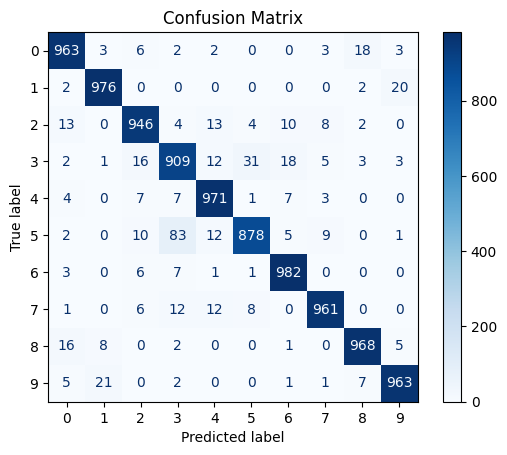

In [9]:
display(ui)